In [1]:
import torch
from sparse_autoencoders import SparseAutoencoder, SparseAutoencoderTopK

In [2]:
input_dim = 2048
mult_factor = 8
hidden_dim = mult_factor * input_dim

#model_name = "models/sae_fr500pop_100epochs.pt"
#model_name = "models/sae_500epochs_500fr_sfe2_LRpatience5.pt"
# model_name = "models/sae_500epochs_10keu.pt"
#model_name = "models/sae_10keu_l26_500epochs.pt"
#model_name = "models/sae_10keu_l26_500epochs_leakyRelu.pt"
model_name = "models/sae_10keu_l26_500epochs_topK.pt"

def load_model(model_name, intput_size, hidden_size):
    #model = SparseAutoencoder(input_dim=intput_size,hidden_dim=hidden_size).to("cuda")
    model = SparseAutoencoderTopK(input_dim=intput_size,hidden_dim=hidden_size,k=2048).to("cuda")

    model.load_state_dict(
        torch.load(model_name)
    )

    model.eval()
    return model

model = load_model(model_name, input_dim, hidden_dim)

In [3]:
from tqdm import tqdm

def inspect_neurons(model, df, hidden_dim, mute=True, device="cuda", top_k=20):
    xs = []

    for arr in df["mean_pooling"].values:
        x = torch.tensor(
            arr,
            dtype=torch.float32
        ).view(-1)
        xs.append(x)

    x = torch.stack(xs).to(device)
    model.eval()
    _, z = model(x)


    activation_sums = []
    for neuron_id in tqdm(range(0, hidden_dim)):
        
        scores = z[:, neuron_id]
        topk = torch.topk(scores, k=top_k)

        activation_sums.append(sum(topk.values))
        if not mute:
            if(sum(topk.values) > 10):
                print(f"    === Neuron {neuron_id} ===")

                print(f"total topk = {sum(topk.values):.4f}")
                for idx, score in zip(topk.indices, topk.values):
                    
                    idx = idx.item()
                    print(f"{score.item():.4f} -> {df.iloc[idx]['prompt']}")
        
    return activation_sums, z

In [4]:
import pandas as pd

data_name = "train_data/mlp_act_eu10k_l26.pkl"
#data_name = "train_data/mlp_act_fr_500.pkl"

df = pd.read_pickle(data_name)


In [6]:
activations_sums, z = inspect_neurons(model, df,hidden_dim=hidden_dim, mute=True)

100%|██████████| 16384/16384 [00:04<00:00, 3467.19it/s]


In [7]:
z.shape

torch.Size([7316, 16384])

In [9]:
def check_if_spare(latent_activation, threshold=1e-3):
    active = (latent_activation.abs() > threshold).float()
    avg_active = active.sum(dim=1).mean()
    print(f"Average active neurons: {avg_active:.4f}")

    density = active.mean()

    print(f"Density: {density.item():.4f}")

check_if_spare(z, 0)

Average active neurons: 1078.5808
Density: 0.0658


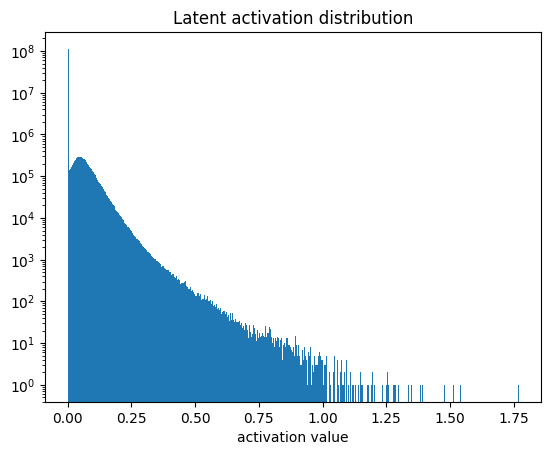

In [15]:
import matplotlib.pyplot as plt

plt.hist(
    z.detach().cpu().numpy().flatten(),
    bins=500,
    log=True
)

plt.title("Latent activation distribution")
plt.xlabel('activation value')
plt.show()

In [18]:
threshold = 0

active = (z > threshold).float()
print(f"avg active neurons: {active.sum(dim=1).mean().item():.3f}")
print(f"density: {active.mean().item():.3f}")
print(f"dead neurons: {(active.sum(dim=0) == 0).float().mean().item():.3f}")

avg active neurons: 1078.581
density: 0.066
dead neurons: 0.924


In [19]:
((z.sum(dim=0) != 0).float().mean()).item()

0.07623291015625

In [20]:
import sqlite3

def add_coords(df, db_path):
    conn = sqlite3.connect(db_path)
    query = """SELECT geonameid, latitude, longitude FROM geonames_gpe"""
    geo_df = pd.read_sql_query(query, conn)
    conn.close()
    df = df.merge(geo_df, on="geonameid", how="left")
    df = df.dropna(subset=["latitude", "longitude"])
    
    return df

In [21]:
DB_PATH = "../geocoding_pipeline/geonames.db"

df = add_coords(df, DB_PATH)

In [25]:
def print_topneurons_topk(df, z, neuron_ids, top_k=5,):
    
    for neuron_id in neuron_ids:

        scores = z[:, neuron_id]

        topk = torch.topk(scores, k=top_k)

        print(f"    === Neuron {neuron_id} ===")

        for i, (idx, score) in enumerate(zip(topk.indices, topk.values)):
            
            idx = idx.item()
            print(f"top {i+1} -> {score.item():.4f} : {df.iloc[idx]['prompt']}")
            # if df.iloc[idx]['prompt'].split(",")[1] != " Brittany":
            #     print(f"{score.item():.4f} -> {df.iloc[idx]['prompt']}")
    

In [23]:
torch.topk(torch.tensor(activations_sums), k=10)

torch.return_types.topk(
values=tensor([24.4700, 19.9423, 19.2353, 18.9429, 18.4542, 18.3259, 18.2577, 17.9331,
        16.7291, 16.3329]),
indices=tensor([ 3114,   559, 14930, 13336,  6559,  2385,  7471, 12101,  9799,  4298]))

In [27]:
print_topneurons_topk(df, z, [559], top_k=4000)

    === Neuron 559 ===
top 1 -> 1.2872 : Limburg an der Lahn
top 2 -> 1.1811 : Neustadt an der Aisch
top 3 -> 1.1005 : Marburg an der Lahn
top 4 -> 1.0857 : Steinheim an der Murr
top 5 -> 1.0419 : Neustadt an der Donau
top 6 -> 1.0113 : Neustadt an der Weinstraße
top 7 -> 1.0087 : Dillingen an der Donau
top 8 -> 0.9965 : Bad Neustadt an der Saale
top 9 -> 0.9902 : Neuburg an der Donau
top 10 -> 0.9743 : Rotenburg an der Fulda
top 11 -> 0.9698 : Dießen am Ammersee
top 12 -> 0.9528 : Giengen an der Brenz
top 13 -> 0.9502 : Neustadt am Rübenberge
top 14 -> 0.9314 : Hanau am Main
top 15 -> 0.9201 : Höchstadt an der Aisch
top 16 -> 0.9197 : Vaihingen an der Enz
top 17 -> 0.9178 : Breisach am Rhein
top 18 -> 0.9029 : Biberach an der Riß
top 19 -> 0.9023 : Gemünden am Main
top 20 -> 0.8977 : Heppenheim an der Bergstrasse
top 21 -> 0.8827 : Bingen am Rhein
top 22 -> 0.8732 : Heidenheim an der Brenz
top 23 -> 0.8714 : Remseck am Neckar
top 24 -> 0.8674 : Geislingen an der Steige
top 25 -> 0.861

In [28]:
import folium
import numpy as np
from tqdm import tqdm
from folium.plugins import HeatMap

def get_neuron_scores(z, neuron_id):
    scores = z[:, neuron_id].detach().cpu().numpy()
    return scores

def fetch_coordinates(conn, geonameid):
    cur = conn.cursor()
    cur.execute("""SELECT latitude, longitude FROM geonames_gpe WHERE geonameid = ?""",(int(geonameid),))
    result = cur.fetchone()
    if result is None:
        return None
    return result[0], result[1]

def create_html_neuron_map(df, z, neuron_id, top_k=None):
    scores = get_neuron_scores(z, neuron_id)
    df = df.copy()
    df["score"] = scores
    if top_k is not None:
        df = df.sort_values("score", ascending=False).head(top_k)

    # France centered map
    m = folium.Map(
        location=[46.6, 2.5],
        zoom_start=6,
        tiles="CartoDB positron"
    )
    heat_data = []
    for _, row in tqdm(df.iterrows(), total=len(df)):

        lat = row["latitude"]
        lon = row["longitude"]
        score = row["score"]

        # color = plt_color(score)
        # opacity = scale_opacity(score)
        # folium.CircleMarker(
        #     location=[lat, lon],
        #     radius= 3 + 5 * abs(score),
        #     color=color,
        #     fill=True,
        #     #opacity=opacity,
        #     popup=f"{row['prompt']} | score={score:.4f}"
        # ).add_to(m)
        heat_data.append([lat, lon, float(score)])

    HeatMap(heat_data, radius=10, blur=15, min_opacity=0.2, max_zoom=10).add_to(m)
    save_path = f"heatmap_neuron{neuron_id}.html"
    m.save(save_path)
    print(f"Saved to {save_path}")
    


def plt_color(score):

    s = score
    if s > 0.5:
        return "red"
    elif s > 0.3:
        return "orange"
    elif s > 0.1:
        return "yellow"
    elif s > 0:
        return "lightgrey"
    else:
        return "blue"
    

def scale_opacity(score, min_opacity=0.03, max_opacity=0.9):
    s = score
    return min_opacity + s * (max_opacity - min_opacity)

In [29]:
import sqlite3
import numpy as np
import pandas as pd
import torch

import geopandas as gpd
import matplotlib.pyplot as plt


def get_neuron_scores(z, neuron_id):
    return (z[:, neuron_id].detach().cpu().numpy())

def fetch_all_coordinates(db_path):
    conn = sqlite3.connect(db_path)
    query = """SELECT geonameid, latitude, longitude FROM geonames_gpe"""
    geo_df = pd.read_sql_query(query, conn)
    conn.close()

    return geo_df


def plot_neuron_france(df, z, neuron_id, figsize=(10, 10), top_k=None):
    scores = get_neuron_scores(z, neuron_id)

    work_df = df.copy()
    work_df["score"] = scores

    if top_k is not None:
        work_df = (work_df.sort_values("score", ascending=False).head(top_k))


    france = gpd.read_file(
        "https://france-geojson.gregoiredavid.fr/repo/regions.geojson"
    )

    fig, ax = plt.subplots(figsize=figsize)

    france.plot(
        ax=ax,
        edgecolor="black",
        color="white"
    )

    low_activations = work_df[work_df["score"] < 0.4]
    high_activations = work_df #[work_df["score"] > 0.4]

    # ax.scatter(low_activations["longitude"], low_activations["latitude"], color="lightgrey", 
    #            alpha=0.5, s=1)

    high_scores = high_activations["score"]
    sizes = 0.1 + 50 * np.log1p(high_scores)
    alphas = 0.05 + 0.5 * np.log1p(high_scores)

    scatter = ax.scatter(
        high_activations["longitude"],
        high_activations["latitude"],
        c=high_activations["score"],
        cmap="OrRd",
        alpha=alphas,
        s=sizes
    )

    plt.colorbar(
        scatter,
        ax=ax,
        label="Neuron activation",
        shrink=0.5
    )

    ax.set_title(f"Neuron {neuron_id} activations")
    
    ax.set_aspect("equal")
    
    ax.set_axis_off()
    ax.set_xlim(-5.5, 10)
    ax.set_ylim(41, 52)

    plt.show()

In [36]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt


def plot_neuron(df, z, neuron_id, figsize=(10, 10), top_k=None):
    scores = get_neuron_scores(z, neuron_id)

    work_df = df.copy()
    work_df["score"] = scores

    if top_k is not None:
        work_df = work_df.sort_values("score", ascending=False).head(top_k)

    # Convert activations to GeoDataFrame (IMPORTANT FIX)
    work_gdf = gpd.GeoDataFrame(
        work_df,
        geometry=gpd.points_from_xy(work_df["longitude"], work_df["latitude"]),
        crs="EPSG:4326"
    )

    # Load France geometry (DOM-TOM included depending on dataset)
    france = gpd.read_file(
        "https://france-geojson.gregoiredavid.fr/repo/regions.geojson"
    ).to_crs("EPSG:4326")

    fig, ax = plt.subplots(figsize=figsize)

    # Base map
    # france.plot(
    #     ax=ax,
    #     edgecolor="black",
    #     color="white",
    #     linewidth=0.8
    # )

    scores = work_gdf["score"].values
    sizes = []
    alphas = []
    for score in scores:
        if score > 0.5:
            sizes.append(2)
            alphas.append(1)
        else:
            sizes.append(1)
            alphas.append(0.5)
    #sizes = 1 + 50 * np.log1p(scores)
    #alphas = np.clip(0.1 + 0.6 * np.log1p(scores), 0.1, 0.9)

    # Scatter plot
    scatter = ax.scatter(
        work_gdf.geometry.x,
        work_gdf.geometry.y,
        c=scores,
        cmap="viridis",
        alpha=alphas,
        s=sizes,
        linewidths=0
    )

    plt.colorbar(scatter, ax=ax, label="Neuron activation", shrink=0.5)

    ax.set_title(f"Neuron {neuron_id} activations")

    #ax.set_axis_off()
    ax.set_aspect("equal")

    ax.set_xlim(-12, 20)
    ax.set_ylim(35, 60)

    plt.show()

In [37]:
torch.topk(torch.tensor(activations_sums), k=10)

torch.return_types.topk(
values=tensor([24.4700, 19.9423, 19.2353, 18.9429, 18.4542, 18.3259, 18.2577, 17.9331,
        16.7291, 16.3329]),
indices=tensor([ 3114,   559, 14930, 13336,  6559,  2385,  7471, 12101,  9799,  4298]))

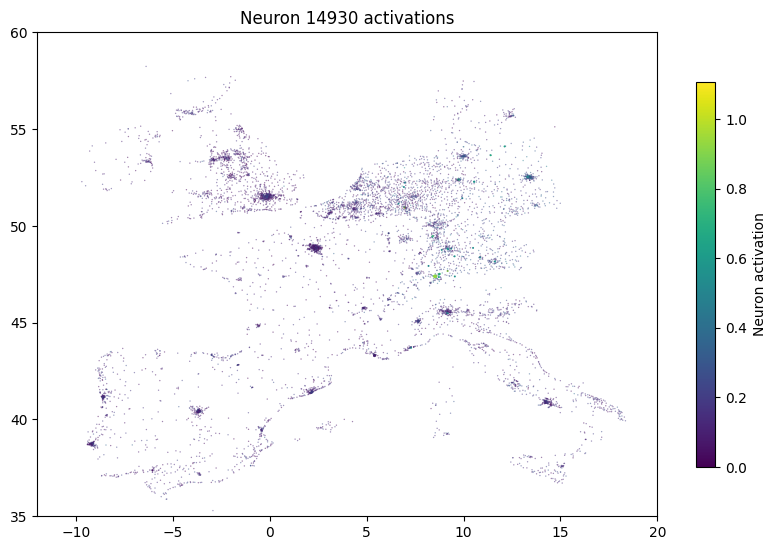

    === Neuron 14930 ===
top 1 -> 1.1077 : Altstadt Sud
top 2 -> 1.0894 : Altstadt Nord
top 3 -> 1.0011 : Zürich (Kreis 4) / Aussersihl
top 4 -> 0.9900 : Zürich (Kreis 4) / Hard
top 5 -> 0.9861 : Zürich (Kreis 3) / Alt-Wiedikon
top 6 -> 0.9851 : Zürich (Kreis 9) / Altstetten
top 7 -> 0.9759 : Zürich (Kreis 6) / Unterstrass
top 8 -> 0.9488 : Zürich (Kreis 4) / Langstrasse
top 9 -> 0.9420 : Altstadt
top 10 -> 0.9383 : Zürich (Kreis 2)
top 11 -> 0.9352 : Zürich (Kreis 6)
top 12 -> 0.9341 : Zürich (Kreis 7)
top 13 -> 0.9318 : Zürich (Kreis 11) / Seebach
top 14 -> 0.9293 : Zürich (Kreis 3)
top 15 -> 0.9277 : Zürich (Kreis 5)
top 16 -> 0.9270 : Zürich (Kreis 9) / Albisrieden
top 17 -> 0.9260 : Zürich (Kreis 3) / Sihlfeld
top 18 -> 0.9244 : Zürich (Kreis 8)
top 19 -> 0.9224 : Zürich (Kreis 11)
top 20 -> 0.9130 : Zürich (Kreis 9)
top 21 -> 0.9102 : Zürich (Kreis 10)
top 22 -> 0.9098 : Zürich (Kreis 10) / Wipkingen
top 23 -> 0.9003 : Zürich (Kreis 2) / Wollishofen
top 24 -> 0.8943 : Zürich (Kre

In [41]:
NEURON_ID = 14930

plot_neuron(df,z,neuron_id=NEURON_ID)
print_topneurons_topk(df, z, [NEURON_ID], top_k=50)

#create_html_neuron_map(df, z, NEURON_ID)

In [164]:
NEURON_ID = 4855

print_topneurons_topk(df, z, [NEURON_ID], top_k=100)

    === Neuron 4855 ===
top 1 -> 0.5559 : Paris 16 Passy
top 2 -> 0.5451 : Paris 12e Arrondissement
top 3 -> 0.5449 : Paris 11e Arrondissement
top 4 -> 0.5349 : Paris 13e Arrondissement
top 5 -> 0.5310 : Marseille 16
top 6 -> 0.5304 : Paris 10e Arrondissement
top 7 -> 0.5267 : Marseille 14
top 8 -> 0.5245 : Marseille 13
top 9 -> 0.5162 : Marseille 15
top 10 -> 0.5119 : Marseille 12
top 11 -> 0.5017 : Marseille 11
top 12 -> 0.4942 : Marseille 07
top 13 -> 0.4919 : Paris 14 Observatoire
top 14 -> 0.4908 : Marseille 06
top 15 -> 0.4896 : Marseille 03
top 16 -> 0.4878 : Marseille 10
top 17 -> 0.4848 : Paris 06 Luxembourg
top 18 -> 0.4773 : Marseille 08
top 19 -> 0.4750 : Marseille 01
top 20 -> 0.4701 : Marseille 02
top 21 -> 0.4614 : Marseille 09
top 22 -> 0.4591 : Paris 03 Temple
top 23 -> 0.4499 : Lyon 03
top 24 -> 0.4465 : Paris 02 Bourse
top 25 -> 0.4398 : Lyon 07
top 26 -> 0.4341 : Paris 13 Gobelins
top 27 -> 0.4340 : Marseille 05
top 28 -> 0.4294 : Lyon 01
top 29 -> 0.4258 : Paris 01

In [43]:
print(
    world[world["ADMIN"] == "France"][
        ["ADMIN", "ISO_A2", "ISO_A3", "ADM0_A3"]
    ]
)

     ADMIN ISO_A2 ISO_A3 ADM0_A3
43  France    -99    -99     FRA


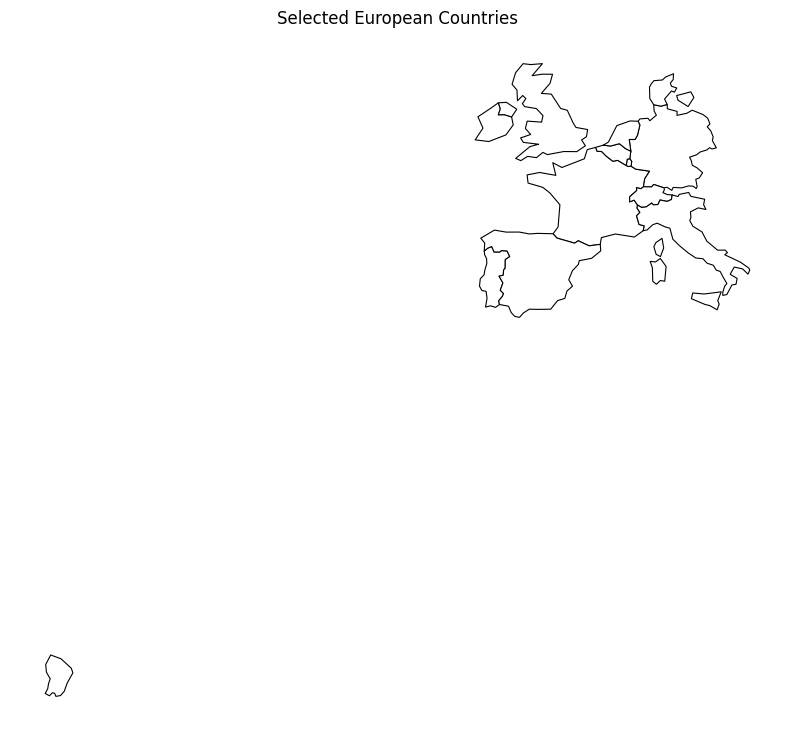

In [44]:
import geopandas as gpd
import matplotlib.pyplot as plt

# ISO2 country codes
countries = [
    "FRA", "BEL", "LUX", "NLD", "DEU", "CHE",
    "ITA", "ESP", "PRT", "GBR", "IRL", "DNK"
]

# Natural Earth countries shapefile (110m resolution)
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

# Load data
world = gpd.read_file(url)

# Filter countries using ADM0_A3 column
selected = world[world["ADM0_A3"].isin(countries)]

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

selected.plot(
    ax=ax,
    color="white",
    edgecolor="black",
    linewidth=0.8
)

ax.set_title("Selected European Countries")
ax.set_axis_off()

plt.show()

MULTIPOLYGON (((-51.65779741067889 4.156232408053029, -52.249337531123956 3.241094468596245, -52.55642473001842 2.504705308437053, -52.939657151894956 2.1248576928756364, -53.41846513529531 2.0533891870159806, -53.554839240113544 2.334896551925951, -53.77852067728892 2.3767027856500818, -54.08806250671725 2.105556545414629, -54.524754197799716 2.3118488631237852, -54.2697051662232 2.7323916691150463, -54.181726040246275 3.1897797713304215, -54.00693050801901 3.6200377465925584, -54.399542202356514 4.212611395683467, -54.47863298197923 4.896755682795586, -53.9580446030709 5.756548163267765, -53.618452928264844 5.6465290389183735, -52.88214128275409 5.409850979021584, -51.8233428615259 4.565768133966131, -51.65779741067889 4.156232408053029)), ((6.186320428094177 49.463802802114515, 6.658229607783568 49.20195831969157, 8.099278598674744 49.01778351500333, 7.593676385131062 48.33301911070372, 7.466759067422231 47.62058197691181, 7.192202182655507 47.44976552997102, 6.736571079138059 47.54

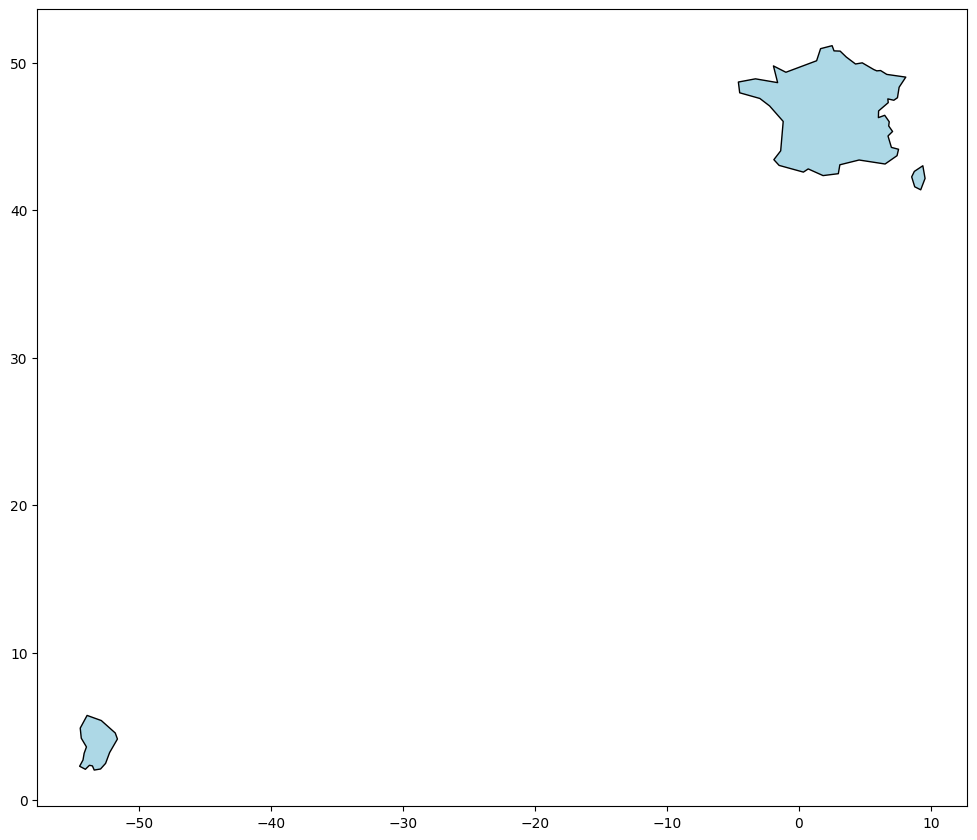

In [50]:
import geopandas as gpd
import matplotlib.pyplot as plt

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)

# France including overseas territories
france = world[world["ADM0_A3"] == "FRA"]

print(france.geometry.iloc[0])

fig, ax = plt.subplots(figsize=(12, 12))

france.plot(
    ax=ax,
    color="lightblue",
    edgecolor="black"
)

plt.show()